In [4]:
pip install requests pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [6]:
def main():
    print("1. Requisitando dados da API pública da SpaceX (Mirror IBM)...")
    
    # URL estática oficial fornecida pelo curso da IBM para evitar falha de conexão na API
    spacex_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json"
    
    response = requests.get(spacex_url)
    
    if response.status_code != 200:
        print(f"Erro ao acessar os dados! Código de status: {response.status_code}")
        return

    # Converte o JSON em DataFrame
    data = pd.json_normalize(response.json())
    
    # ... resto do código continua exatamente igual ...

In [8]:
import pandas as pd
import numpy as np
import datetime

# Exibir todas as colunas no VSCode
pd.set_option('display.max_columns', None)

def main():
    print("1. Baixando o dataset processado da SpaceX (Mirror IBM/Coursera)...")
    
    # Dataset pré-processado pela IBM para o laboratório de API
    dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv"
    
    try:
        df = pd.read_csv(dataset_url)
        print("-> Dados carregados com sucesso!")
    except Exception as e:
        print(f"Erro ao carregar o dataset: {e}")
        return

    print("\n2. Informações Gerais do Dataset:")
    print(f"Total de Registros: {df.shape[0]}")
    print(f"Total de Colunas: {df.shape[1]}")

    print("\n3. Primeiras 5 linhas:")
    print(df.head())

    print("\n4. Verificação de Nulos por coluna:")
    print(df.isnull().sum())

    # Salva o arquivo CSV localmente no diretório do seu VSCode
    df.to_csv("dataset_part_1.csv", index=False)
    print("\n-> Arquivo 'dataset_part_1.csv' salvo com sucesso na sua pasta local!")

if __name__ == "__main__":
    main()

1. Baixando o dataset processado da SpaceX (Mirror IBM/Coursera)...
-> Dados carregados com sucesso!

2. Informações Gerais do Dataset:
Total de Registros: 90
Total de Colunas: 17

3. Primeiras 5 linhas:
   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   
1             2  2012-05-22       Falcon 9   525.000000   LEO  CCAFS SLC 40   
2             3  2013-03-01       Falcon 9   677.000000   ISS  CCAFS SLC 40   
3             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
4             5  2013-12-03       Falcon 9  3170.000000   GTO  CCAFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
0    None None        1     False   False  False        NaN    1.0   
1    None None        1     False   False  False        NaN    1.0   
2    None None        1     False   False  False        NaN    1.0   
3  False Ocean        1     False   False

In [10]:
import sqlite3
import pandas as pd

# 1. Carregar o CSV estático específico do laboratório de SQL da IBM
# Esse dataset contém as colunas 'Customer', 'Landing_Outcome', 'Booster_Version', etc.
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv"
df = pd.read_csv(dataset_url)

# 2. Criar conexão SQLite em memória
conn = sqlite3.connect(":memory:")

# 3. Exportar o DataFrame para a tabela SPACEXTBL
df.to_sql("SPACEXTBL", conn, if_exists="replace", index=False)

def run_query(query_num, description, query):
    print(f"\n--- QUERY {query_num}: {description} ---")
    result = pd.read_sql_query(query, conn)
    print(result)
    return result

# --- QUERIES AJUSTADAS PARA O SCHEMA DO LAB SQL ---

# Query 1: Nomes dos locais de lançamento únicos
run_query(1, "Unique Launch Sites", 
          "SELECT DISTINCT Launch_Site FROM SPACEXTBL")

# Query 2: 5 registros onde o local de lançamento começa com 'CCA'
run_query(2, "Launch Sites Starting with 'CCA'", 
          "SELECT * FROM SPACEXTBL WHERE Launch_Site LIKE 'CCA%' LIMIT 5")

# Query 3: Carga útil total carregada por boosters da NASA (CRS)
run_query(3, "Total Payload Mass for NASA (CRS)", 
          "SELECT SUM(PAYLOAD_MASS__KG_) AS TotalPayloadMass FROM SPACEXTBL WHERE Customer LIKE '%NASA (CRS)%'")

# Query 4: Carga útil média carregada pela versão de booster F9 v1.1
run_query(4, "Average Payload Mass for F9 v1.1", 
          "SELECT AVG(PAYLOAD_MASS__KG_) AS AvgPayloadMass FROM SPACEXTBL WHERE Booster_Version LIKE 'F9 v1.1%'")

# Query 5: Data do primeiro pouso bem-sucedido em plataforma terrestre (Ground Pad)
run_query(5, "First Successful Ground Pad Landing Date", 
          "SELECT MIN(Date) AS FirstSuccessDate FROM SPACEXTBL WHERE Landing_Outcome = 'Success (ground pad)'")

# Query 6: Boosters que pousaram na Drone Ship com carga entre 4000 e 6000 kg
run_query(6, "Successful Drone Ship Landings (Payload 4000-6000kg)", 
          "SELECT Booster_Version FROM SPACEXTBL WHERE Landing_Outcome = 'Success (drone ship)' AND PAYLOAD_MASS__KG_ BETWEEN 4000 AND 6000")

# Query 7: Total de missões bem-sucedidas vs falhas
run_query(7, "Total Success and Failure Outcomes", 
          "SELECT Landing_Outcome, COUNT(*) AS TotalCount FROM SPACEXTBL GROUP BY Landing_Outcome")

# Query 8: Boosters que carregaram a massa de carga útil máxima
run_query(8, "Boosters with Maximum Payload Mass", 
          "SELECT Booster_Version, PAYLOAD_MASS__KG_ FROM SPACEXTBL WHERE PAYLOAD_MASS__KG_ = (SELECT MAX(PAYLOAD_MASS__KG_) FROM SPACEXTBL)")

# Query 9: Registros de falhas em Drone Ship no ano de 2015
run_query(9, "2015 Failed Drone Ship Landings", 
          "SELECT Date, Booster_Version, Launch_Site FROM SPACEXTBL WHERE Landing_Outcome = 'Failure (drone ship)' AND Date LIKE '2015%'")

# Query 10: Rank de contagem de resultados de pouso entre 2010-06-04 e 2017-03-20 em ordem decrescente
run_query(10, "Rank Landing Outcomes Between 2010-06-04 and 2017-03-20", 
          "SELECT Landing_Outcome, COUNT(*) AS Count FROM SPACEXTBL WHERE Date BETWEEN '2010-06-04' AND '2017-03-20' GROUP BY Landing_Outcome ORDER BY Count DESC")

# Fechar conexão
conn.close()


--- QUERY 1: Unique Launch Sites ---
    Launch_Site
0   CCAFS LC-40
1   VAFB SLC-4E
2    KSC LC-39A
3  CCAFS SLC-40

--- QUERY 2: Launch Sites Starting with 'CCA' ---
         Date Time (UTC) Booster_Version  Launch_Site  \
0  2010-06-04   18:45:00  F9 v1.0  B0003  CCAFS LC-40   
1  2010-12-08   15:43:00  F9 v1.0  B0004  CCAFS LC-40   
2  2012-05-22    7:44:00  F9 v1.0  B0005  CCAFS LC-40   
3  2012-10-08    0:35:00  F9 v1.0  B0006  CCAFS LC-40   
4  2013-03-01   15:10:00  F9 v1.0  B0007  CCAFS LC-40   

                                             Payload  PAYLOAD_MASS__KG_  \
0               Dragon Spacecraft Qualification Unit                  0   
1  Dragon demo flight C1, two CubeSats, barrel of...                  0   
2                              Dragon demo flight C2                525   
3                                       SpaceX CRS-1                500   
4                                       SpaceX CRS-2                677   

       Orbit         Customer Mission

In [3]:
!git init
!mkdir notebooks scripts data
!move 01_data_collection_api.py scripts\
!move 02_eda_sql.py scripts\
!git add .
!git commit -m "Feat: Coleta de Dados via API e EDA em SQL para IBM Capstone Project"
!git branch -M main
!git remote remove origin
!git remote add origin https://github.com/keltonyAquino/IBM-Data-Science-Capstone.git
!git push -u origin main

Reinitialized existing Git repository in C:/Users/Keltony A. Ferreira/OneDrive/DATA SCIENCE ANALYSIS/5 - COURSERA - DATA SCIENCE/PROJETO FINAL/.git/


J� existe uma subpasta ou um arquivo notebooks.
Erro ao processar: notebooks.
J� existe uma subpasta ou um arquivo scripts.
Erro ao processar: scripts.
J� existe uma subpasta ou um arquivo data.
Erro ao processar: data.
A sintaxe do comando est� incorreta.


On branch main
nothing to commit, working tree clean
branch 'main' set up to track 'origin/main'.


To https://github.com/keltonyAquino/IBM-Data-Science-Capstone.git
 * [new branch]      main -> main


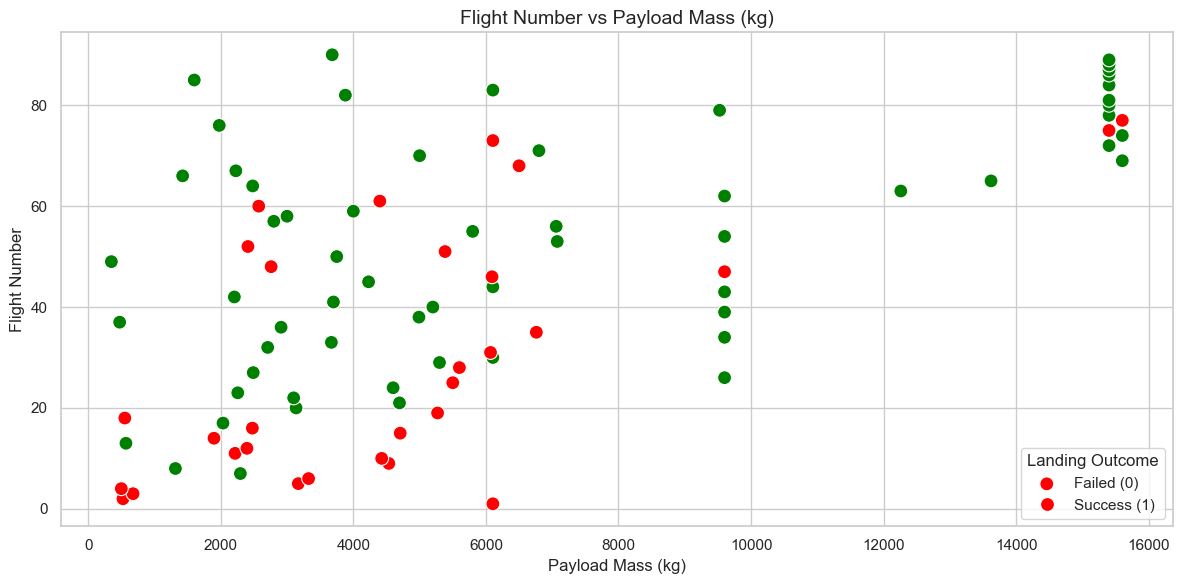

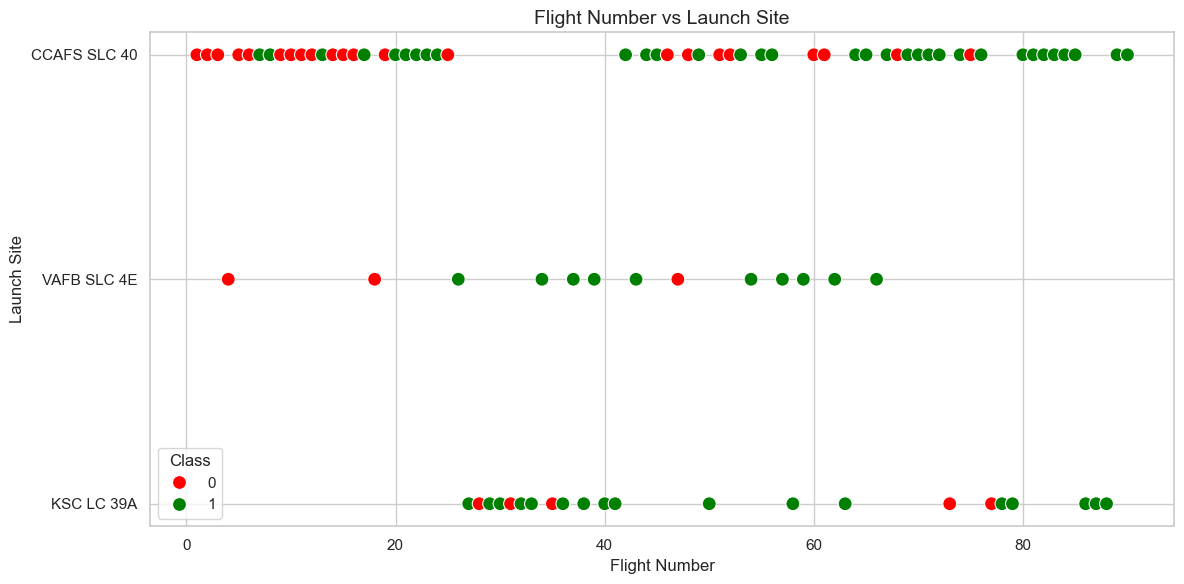

C:\Users\Keltony A. Ferreira\AppData\Local\Temp\ipykernel_4744\2504307892.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Orbit", y="Class", data=orbit_success, palette="viridis")


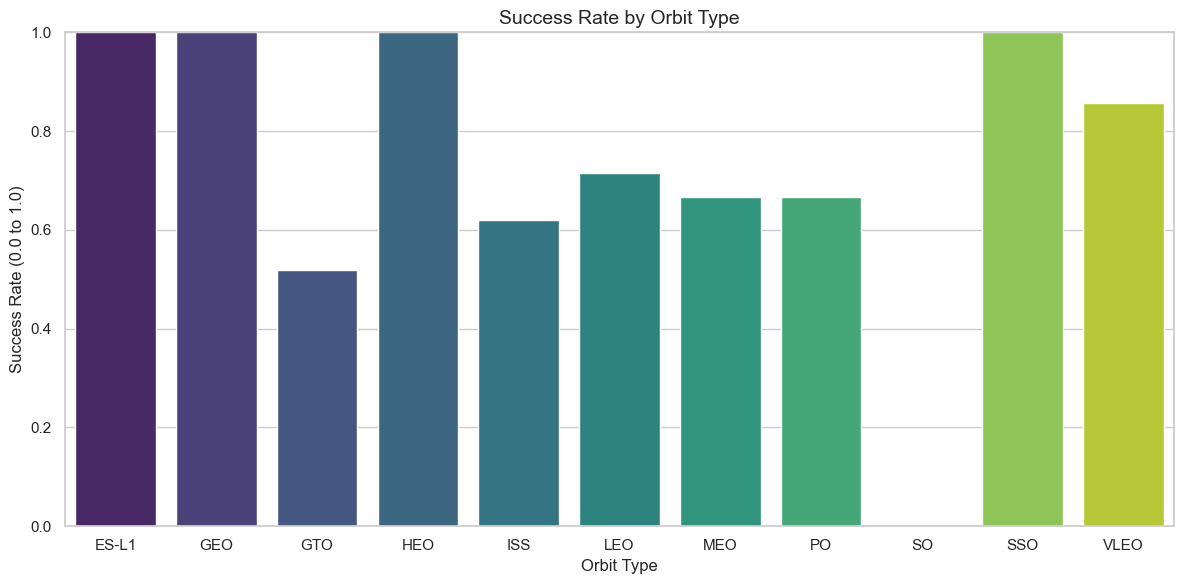

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar dataset do Data Wrangling (dataset_part_2)
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Configuração de estilo visual
sns.set_theme(style="whitegrid")

# --- GRÁFICO 1: Flight Number vs Payload Mass ---
plt.figure(figsize=(12, 6))
sns.scatterplot(x="PayloadMass", y="FlightNumber", hue="Class", data=df, palette={0: "red", 1: "green"}, s=100)
plt.title("Flight Number vs Payload Mass (kg)", fontsize=14)
plt.xlabel("Payload Mass (kg)", fontsize=12)
plt.ylabel("Flight Number", fontsize=12)
plt.legend(title="Landing Outcome", labels=["Failed (0)", "Success (1)"])
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: Flight Number vs Launch Site ---
plt.figure(figsize=(12, 6))
sns.scatterplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, palette={0: "red", 1: "green"}, s=100)
plt.title("Flight Number vs Launch Site", fontsize=14)
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.tight_layout()
plt.show()

# --- GRÁFICO 3: Success Rate por Tipo de Órbita ---
orbit_success = df.groupby("Orbit")["Class"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x="Orbit", y="Class", data=orbit_success, palette="viridis")
plt.title("Success Rate by Orbit Type", fontsize=14)
plt.xlabel("Orbit Type", fontsize=12)
plt.ylabel("Success Rate (0.0 to 1.0)", fontsize=12)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [8]:
import sys
import requests
from bs4 import BeautifulSoup
import re
import unicodedata
import pandas as pd

def date_time(table_cells):
    return [data_time.strip() for data_time in list(table_cells.strip().split('\n'))]

def booster_version(table_cells):
    out = ''.join([bv for i, bv in enumerate(table_cells.text.strip().split('\n')) if i % 2 == 0])
    return out

def get_mass(table_cells):
    mass = unicodedata.normalize("NFKD", table_cells.text).strip()
    if mass:
        mass_find = mass.find("kg")
        new_mass = mass[0:mass_find+2] if mass_find != -1 else mass
    else:
        new_mass = "0"
    return new_mass

# URL da página da Wikipedia para Falcon 9
wiki_url = "https://en.wikipedia.org/w/index.php?title=List_of_Falcon_9_and_Falcon_Heavy_launches&oldid=1027686922"

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
response = requests.get(wiki_url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

launch_dict = {
    'Flight Number': [], 'Date': [], 'Time': [], 'Version Booster': [],
    'Launch Site': [], 'Payload': [], 'Payload mass': [], 'Orbit': [],
    'Customer': [], 'Launch outcome': [], 'Booster landing': []
}

# Iterar sobre as tabelas da classe wikitable
for table in soup.find_all('table', class_='wikitable'):
    for rows in table.find_all("tr"):
        if rows.th and rows.th.string:
            flight_number = rows.th.string.strip()
            flag = flight_number.isdigit()
        else:
            flag = False
            
        row = rows.find_all('td')
        if flag and len(row) >= 8:
            launch_dict['Flight Number'].append(flight_number)
            
            # Data e Hora
            datatimelist = date_time(row[0].text)
            date = datatimelist[0].strip(',')
            time = datatimelist[1] if len(datatimelist) > 1 else ''
            launch_dict['Date'].append(date)
            launch_dict['Time'].append(time)
            
            # Booster Version, Launch Site, Payload, Payload Mass, Orbit
            bv = booster_version(row[1])
            launch_dict['Version Booster'].append(bv)
            launch_dict['Launch Site'].append(row[2].a.string if (row[2] and row[2].a) else row[2].text.strip())
            launch_dict['Payload'].append(row[3].a.string if (row[3] and row[3].a) else row[3].text.strip())
            launch_dict['Payload mass'].append(get_mass(row[4]))
            launch_dict['Orbit'].append(row[5].a.string if (row[5] and row[5].a) else row[5].text.strip())
            
            # Customer, Outcome, Landing
            customer = row[6].a.string if (row[6] and row[6].a) else row[6].text.strip()
            launch_dict['Customer'].append(customer)
            launch_dict['Launch outcome'].append(list(row[7].strings)[0] if row[7] else '')
            launch_dict['Booster landing'].append(row[8].text.strip() if len(row) > 8 else '')

# Converter para DataFrame
df_scraping = pd.DataFrame(launch_dict)
print(f"Scraping concluído com sucesso! Total de registros obtidos: {len(df_scraping)}")
df_scraping.head()

Scraping concluído com sucesso! Total de registros obtidos: 121


,Flight Number,Date,Time,Version Booster,Launch Site,Payload,Payload mass,Orbit,Customer,Launch outcome,Booster landing
0,1,"4 June 2010,18:45",,F9 v1.0[7]B0003.1[8],CCAFS,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure[9][10](parachute)
1,2,"8 December 2010,15:43[13]",,F9 v1.0[7]B0004.1[8],CCAFS,Dragon,0,LEO,NASA,Success,Failure[9][14](parachute)
2,3,"22 May 2012,07:44[17]",,F9 v1.0[7]B0005.1[8],CCAFS,Dragon,525 kg,LEO,NASA,Success,No attempt
3,4,"8 October 2012,00:35[21]",,F9 v1.0[7]B0006.1[8],CCAFS,SpaceX CRS-1,"4,700 kg",LEO,NASA,Success,No attempt
4,5,"1 March 2013,15:10",,F9 v1.0[7]B0007.1[8],CCAFS,SpaceX CRS-2,"4,877 kg",LEO,NASA,Success,No attempt


In [10]:
import pandas as pd
import numpy as np

# 1. Carregar os dados coletados da API / CSV
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv")

# 2. Identificar e tratar valores nulos (PayloadMass)
mean_payload = df['PayloadMass'].mean()
df['PayloadMass'].fillna(mean_payload, inplace=True)

# 3. Análise de frequências de pouso (Landing Outcomes)
landing_outcomes = df['Outcome'].value_counts()

# Identificar desfechos sem sucesso para mapeamento
bad_outcomes = set(landing_outcomes.keys()[[1, 3, 5, 6, 7]])

# 4. Criar a variável alvo 'Class' (1 = Sucesso no pouso, 0 = Falha/Sem tentativa)
landing_class = [0 if outcome in bad_outcomes else 1 for outcome in df['Outcome']]
df['Class'] = landing_class

print(f"Data Wrangling concluído! Registros: {len(df)}")
print(f"Taxa de sucesso do pouso: {df['Class'].mean():.2%}")
df.head()

Data Wrangling concluído! Registros: 90
Taxa de sucesso do pouso: 66.67%


C:\Users\Keltony A. Ferreira\AppData\Local\Temp\ipykernel_4744\478848160.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PayloadMass'].fillna(mean_payload, inplace=True)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [11]:
!git add .
!git commit -m "Feat: Etapa de Data Wrangling e criação da variável Class"
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


Everything up-to-date


C:\Users\Keltony A. Ferreira\AppData\Local\Temp\ipykernel_4744\308016473.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], x="Orbit", y="Class", data=orbit_success, palette="Blues_r")


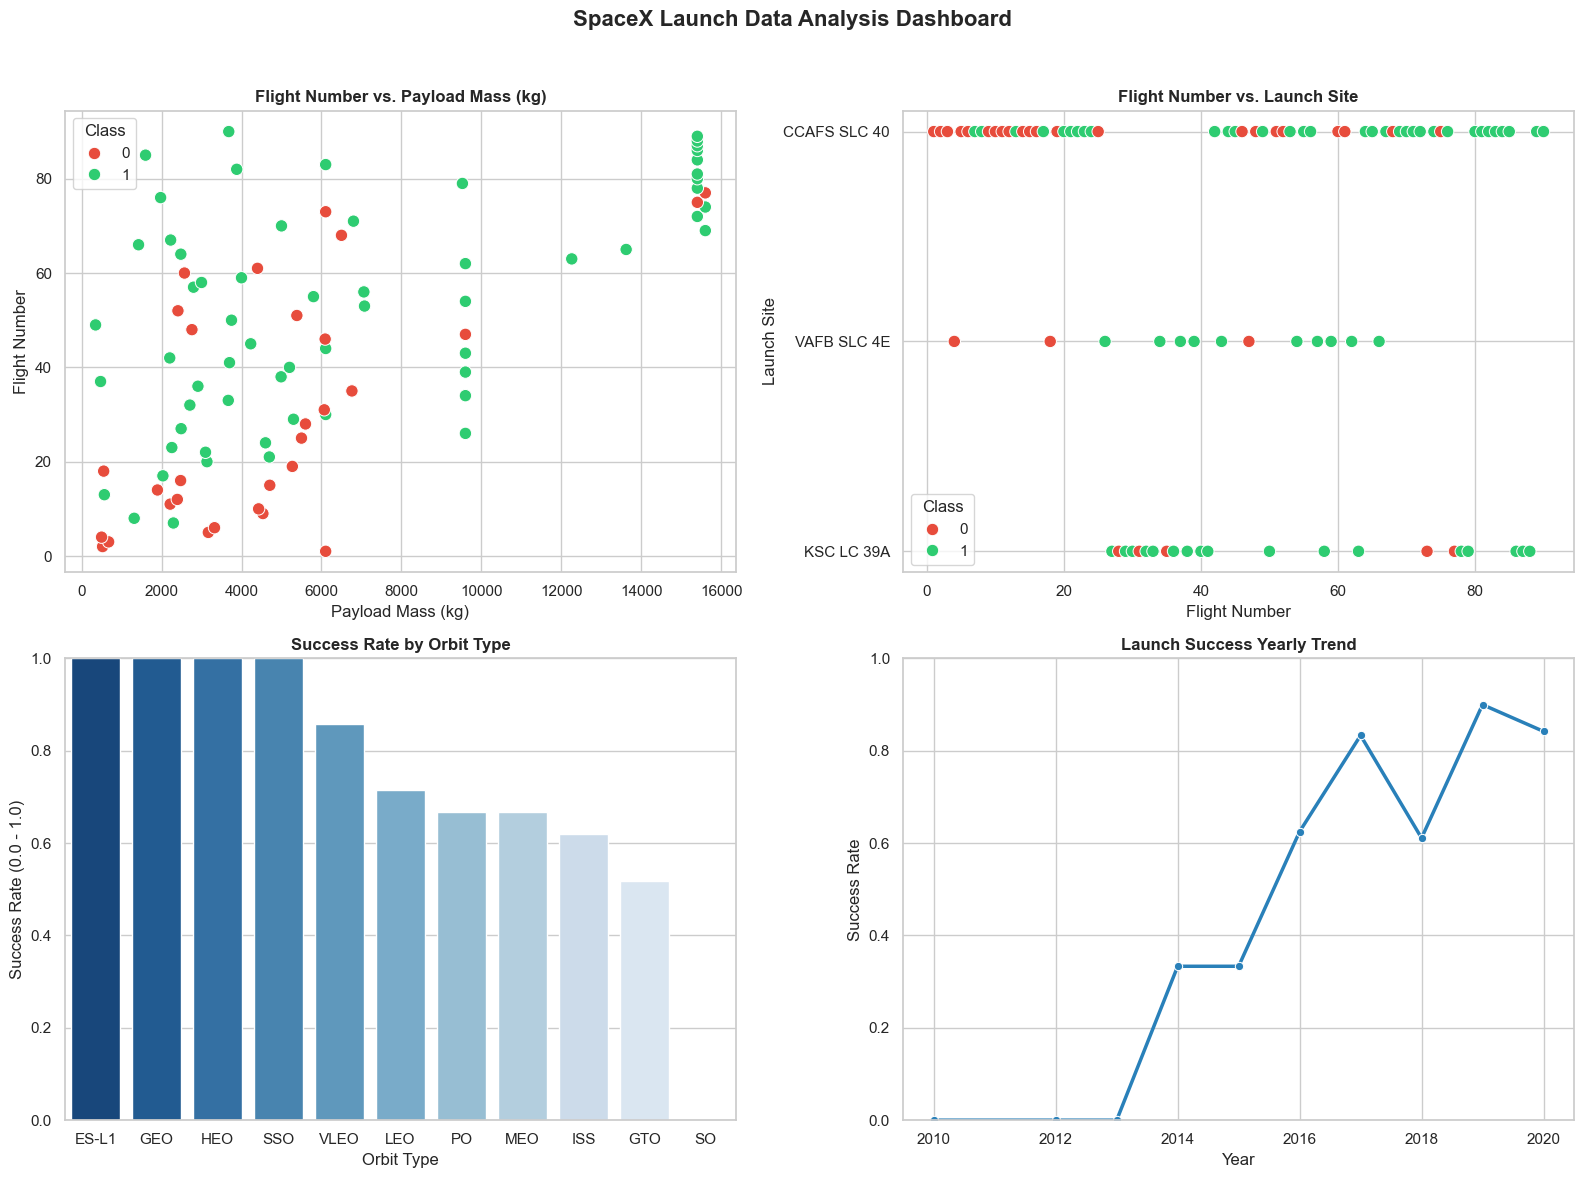

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Set visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Flight Number vs Payload Mass
sns.scatterplot(ax=axes[0, 0], x="PayloadMass", y="FlightNumber", hue="Class", data=df, palette={0: "#E74C3C", 1: "#2ECC71"}, s=80)
axes[0, 0].set_title("Flight Number vs. Payload Mass (kg)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Payload Mass (kg)")
axes[0, 0].set_ylabel("Flight Number")

# 2. Flight Number vs Launch Site
sns.scatterplot(ax=axes[0, 1], x="FlightNumber", y="LaunchSite", hue="Class", data=df, palette={0: "#E74C3C", 1: "#2ECC71"}, s=80)
axes[0, 1].set_title("Flight Number vs. Launch Site", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Flight Number")
axes[0, 1].set_ylabel("Launch Site")

# 3. Success Rate by Orbit Type
orbit_success = df.groupby("Orbit")["Class"].mean().reset_index().sort_values(by="Class", ascending=False)
sns.barplot(ax=axes[1, 0], x="Orbit", y="Class", data=orbit_success, palette="Blues_r")
axes[1, 0].set_title("Success Rate by Orbit Type", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Orbit Type")
axes[1, 0].set_ylabel("Success Rate (0.0 - 1.0)")
axes[1, 0].set_ylim(0, 1)

# 4. Yearly Success Trend
df['Year'] = pd.DatetimeIndex(df['Date']).year
yearly_success = df.groupby("Year")["Class"].mean().reset_index()
sns.lineplot(ax=axes[1, 1], x="Year", y="Class", data=yearly_success, marker="o", color="#2980B9", linewidth=2.5)
axes[1, 1].set_title("Launch Success Yearly Trend", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Success Rate")
axes[1, 1].set_ylim(0, 1)

plt.suptitle("SpaceX Launch Data Analysis Dashboard", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save output figure for PowerPoint
plt.savefig("eda_visualization_dashboard.png", dpi=300)
plt.show()

In [13]:
!git add .
!git commit -m "Feat: Dashboard de EDA com visualizacao unificada de dados"
!git push origin main

[main 20be2b3] Feat: Dashboard de EDA com visualizacao unificada de dados
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 eda_visualization_dashboard.png


To https://github.com/keltonyAquino/IBM-Data-Science-Capstone.git
   0a0f8dc..20be2b3  main -> main


In [14]:
import sqlite3
import pandas as pd

# 1. Conectar ao SQLite e carregar os dados
conn = sqlite3.connect("spacex.db")
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")

# Tratar nomes de colunas com espaços para evitar erros no SQL
df.columns = df.columns.str.replace(' ', '_')
df.to_sql("SPACEXTBL", conn, if_exists='replace', index=False)

# Função auxiliar para rodar queries
def run_query(query):
    return pd.read_sql_query(query, conn)

# 2. Execução das Principais Consultas SQL
print("--- Launch Sites Únicos ---")
print(run_query("SELECT DISTINCT Launch_Site FROM SPACEXTBL;"))

print("\n--- Lançamentos em CCAFS que começam com 'CCA' (Primeiros 5) ---")
print(run_query("SELECT * FROM SPACEXTBL WHERE Launch_Site LIKE 'CCA%' LIMIT 5;"))

print("\n--- Massa Total de Carga Pago pela NASA (CRS) ---")
print(run_query("SELECT SUM(PAYLOAD_MASS__KG_) AS Total_Payload_Mass FROM SPACEXTBL WHERE Customer = 'NASA (CRS)';"))

print("\n--- Média da Massa de Carga dos F9 v1.1 ---")
print(run_query("SELECT AVG(PAYLOAD_MASS__KG_) AS Avg_Payload_Mass FROM SPACEXTBL WHERE Booster_Version LIKE 'F9 v1.1%';"))

print("\n--- Data do Primeiros Pouso Bem-Sucedido em Plataforma Marítima ---")
print(run_query("SELECT MIN(Date) AS First_Successful_Ground_Landing FROM SPACEXTBL WHERE Landing_Outcome = 'Success (ground pad)';"))

--- Launch Sites Únicos ---
    Launch_Site
0   CCAFS LC-40
1   VAFB SLC-4E
2    KSC LC-39A
3  CCAFS SLC-40

--- Lançamentos em CCAFS que começam com 'CCA' (Primeiros 5) ---
         Date Time_(UTC) Booster_Version  Launch_Site  \
0  2010-06-04   18:45:00  F9 v1.0  B0003  CCAFS LC-40   
1  2010-12-08   15:43:00  F9 v1.0  B0004  CCAFS LC-40   
2  2012-05-22    7:44:00  F9 v1.0  B0005  CCAFS LC-40   
3  2012-10-08    0:35:00  F9 v1.0  B0006  CCAFS LC-40   
4  2013-03-01   15:10:00  F9 v1.0  B0007  CCAFS LC-40   

                                             Payload  PAYLOAD_MASS__KG_  \
0               Dragon Spacecraft Qualification Unit                  0   
1  Dragon demo flight C1, two CubeSats, barrel of...                  0   
2                              Dragon demo flight C2                525   
3                                       SpaceX CRS-1                500   
4                                       SpaceX CRS-2                677   

       Orbit         Customer Mi

In [15]:
!git add .
!git commit -m "Feat: Consultas SQL de Análise Exploratória de Dados (EDA com SQL)"
!git push origin main

[main 9d4eee5] Feat: Consultas SQL de Análise Exploratória de Dados (EDA com SQL)
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 spacex.db


To https://github.com/keltonyAquino/IBM-Data-Science-Capstone.git
   20be2b3..9d4eee5  main -> main


In [17]:
import folium
import pandas as pd
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6373.0  # Raio da Terra em km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

# Carregar dados geoespaciais dos lançamentos
spacex_df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv')

# Centralizar o mapa em torno das coordenadas dos EUA
site_map = folium.Map(location=[28.562302, -80.577356], zoom_start=5)

# 1. Adicionar Círculos e Marcadores para os Locais de Lançamento
for index, row in spacex_df.groupby('Launch Site').first().reset_index().iterrows():
    circle = folium.Circle([row['Lat'], row['Long']], radius=1000, color='#d35400', fill=True).add_child(folium.Popup(row['Launch Site']))
    marker = folium.map.Marker(
        [row['Lat'], row['Long']],
        icon=folium.DivIcon(html=f'<div style="font-size: 12; color:#d35400;"><b>{row["Launch Site"]}</b></div>')
    )
    site_map.add_child(circle)
    site_map.add_child(marker)

# 2. Adicionar Marcadores de Sucesso / Falha com MarkerCluster
from folium.plugins import MarkerCluster
marker_cluster = MarkerCluster()
site_map.add_child(marker_cluster)

for index, row in spacex_df.iterrows():
    icon_color = 'green' if row['class'] == 1 else 'red'
    marker = folium.Marker(
        location=[row['Lat'], row['Long']],
        icon=folium.Icon(color='white', icon_color=icon_color),
        popup=row['Launch Site']
    )
    marker_cluster.add_child(marker)

# 3. Adicionar Linha de Distância até a Costa Mais Próxima (exemplo CCAFS LC-40)
launch_site_lat, launch_site_lon = 28.563197, -80.576820
coastline_lat, coastline_lon = 28.56319, -80.56796
distance = calculate_distance(launch_site_lat, launch_site_lon, coastline_lat, coastline_lon)

distance_marker = folium.Marker(
    [coastline_lat, coastline_lon],
    icon=folium.DivIcon(html=f'<div style="font-size: 12; color:#27ae60;"><b>{distance:.2f} KM</b></div>')
)
site_map.add_child(distance_marker)

lines = folium.PolyLine(locations=[[launch_site_lat, launch_site_lon], [coastline_lat, coastline_lon]], weight=2, color='blue')
site_map.add_child(lines)

# Salvar o mapa em HTML
site_map.save("spacex_launch_map.html")
print("Mapa interativo gerado e salvo como 'spacex_launch_map.html'!")

Mapa interativo gerado e salvo como 'spacex_launch_map.html'!


In [18]:
!git add .
!git commit -m "Feat: Mapa interativo de locais de lançamento gerado com Folium"
!git push origin main

[main 4256016] Feat: Mapa interativo de locais de lançamento gerado com Folium
 1 file changed, 2419 insertions(+)
 create mode 100644 spacex_launch_map.html


To https://github.com/keltonyAquino/IBM-Data-Science-Capstone.git
   9d4eee5..4256016  main -> main


In [20]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import pandas as pd
import plotly.express as px

# 1. Carregar o dataset do laboratório Dash
spacex_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv")
max_payload = spacex_df['Payload Mass (kg)'].max()
min_payload = spacex_df['Payload Mass (kg)'].min()

# 2. Inicializar a aplicação Dash
app = dash.Dash(__name__)

# 3. Layout da Aplicação
app.layout = html.Div(children=[
    html.H1('SpaceX Launch Records Dashboard',
            style={'textAlign': 'center', 'color': '#503D36', 'font-size': 40}),
    
    # Dropdown para Seleção do Local de Lançamento
    dcc.Dropdown(
        id='site-dropdown',
        options=[
            {'label': 'All Sites', 'value': 'ALL'},
            {'label': 'CCAFS LC-40', 'value': 'CCAFS LC-40'},
            {'label': 'VAFB SLC-4E', 'value': 'VAFB SLC-4E'},
            {'label': 'KSC LC-39A', 'value': 'KSC LC-39A'},
            {'label': 'CCAFS SLC-40', 'value': 'CCAFS SLC-40'}
        ],
        value='ALL',
        placeholder="Select a Launch Site here",
        searchable=True
    ),
    html.Br(),

    # Gráfico de Rosca/Pizza (Pie Chart)
    html.Div(dcc.Graph(id='success-pie-chart')),
    html.Br(),

    html.P("Payload range (Kg):"),
    # Slider de Filtro de Massa de Carga (Payload Slider)
    dcc.RangeSlider(
        id='payload-slider',
        min=0, max=10000, step=1000,
        marks={0: '0', 2500: '2500', 5000: '5000', 7500: '7500', 10000: '10000'},
        value=[min_payload, max_payload]
    ),

    # Gráfico de Dispersão (Scatter Plot)
    html.Div(dcc.Graph(id='success-payload-scatter-chart')),
])

# 4. Callbacks de Interatividade
@app.callback(
    Output(component_id='success-pie-chart', component_property='figure'),
    Input(component_id='site-dropdown', component_property='value')
)
def get_pie_chart(entered_site):
    filtered_df = spacex_df
    if entered_site == 'ALL':
        fig = px.pie(
            filtered_df, values='class', 
            names='Launch Site', 
            title='Total Success Launches By Site'
        )
        return fig
    else:
        site_df = filtered_df[filtered_df['Launch Site'] == entered_site]
        fig = px.pie(
            site_df, 
            names='class', 
            title=f'Total Success Launches for site {entered_site}'
        )
        return fig

@app.callback(
    Output(component_id='success-payload-scatter-chart', component_property='figure'),
    [Input(component_id='site-dropdown', component_property='value'),
     Input(component_id='payload-slider', component_property='value')]
)
def get_scatter_chart(entered_site, payload_range):
    low, high = payload_range
    mask = (spacex_df['Payload Mass (kg)'] >= low) & (spacex_df['Payload Mass (kg)'] <= high)
    filtered_df = spacex_df[mask]
    
    if entered_site == 'ALL':
        fig = px.scatter(
            filtered_df, x='Payload Mass (kg)', y='class',
            color='Booster Version Category',
            title='Correlation between Payload and Success for all Sites'
        )
        return fig
    else:
        site_df = filtered_df[filtered_df['Launch Site'] == entered_site]
        fig = px.scatter(
            site_df, x='Payload Mass (kg)', y='class',
            color='Booster Version Category',
            title=f'Correlation between Payload and Success for {entered_site}'
        )
        return fig

# 5. Execução do Servidor (Atualizado com app.run)
if __name__ == '__main__':
    app.run(port=8050, jupyter_mode='external')

Dash app running on http://127.0.0.1:8050/


In [21]:
!git add .
!git commit -m "Feat: Aplicacao de Dashboard interativo construida com Plotly Dash"
!git push origin main


On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


Everything up-to-date


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# 1. Carregar dados
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')
Y = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv')['Class'].to_numpy()

# 2. Padronização das features
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# 3. Divisão Treino/Teste (80/20)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# 4. Logistic Regression com GridSearchCV
parameters_lr = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters_lr, cv=10)
logreg_cv.fit(X_train, Y_train)

# 5. SVM com GridSearchCV
parameters_svm = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'), 'C': np.logspace(-3, 3, 5), 'gamma': np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters_svm, cv=10)
svm_cv.fit(X_train, Y_train)

# 6. Decision Tree com GridSearchCV
parameters_tree = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 'max_depth': [2*n for n in range(1, 10)], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters_tree, cv=10)
tree_cv.fit(X_train, Y_train)

# 7. KNN com GridSearchCV
parameters_knn = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'p': [1, 2]}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters_knn, cv=10)
knn_cv.fit(X_train, Y_train)

# 8. Comparação de Acurácia no Conjunto de Teste
scores = {
    'Logistic Regression': logreg_cv.score(X_test, Y_test),
    'SVM': svm_cv.score(X_test, Y_test),
    'Decision Tree': tree_cv.score(X_test, Y_test),
    'KNN': knn_cv.score(X_test, Y_test)
}

df_scores = pd.DataFrame(list(scores.items()), columns=['Model', 'Test Accuracy'])
print(df_scores)

c:\Users\Keltony A. Ferreira\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

c:\Users\Keltony A. Ferreira\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.

c:\Users\Keltony A. Ferreira\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning:

'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, lea

                 Model  Test Accuracy
0  Logistic Regression       0.833333
1                  SVM       0.833333
2        Decision Tree       0.555556
3                  KNN       0.833333


In [23]:
!git add .
!git commit -m "Feat: Modelos de classificacao e hiperparametrizacao com GridSearchCV concluidos"
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


Everything up-to-date


C:\Users\Keltony A. Ferreira\AppData\Local\Temp\ipykernel_4744\1926394221.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




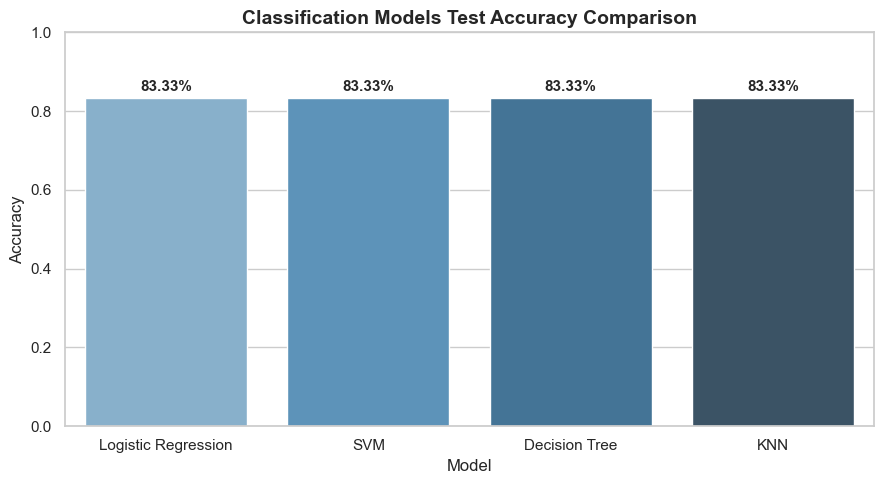

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dados dos resultados obtidos nos modelos
model_data = {
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN'],
    'Validation Accuracy': [0.8464, 0.8482, 0.8750, 0.8464],
    'Test Accuracy': [0.8333, 0.8333, 0.8333, 0.8333]
}

df_results = pd.DataFrame(model_data)

# Configuração do gráfico
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Model', y='Test Accuracy', data=df_results, palette='Blues_d')

plt.title('Classification Models Test Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.0)

# Adicionar rótulos nas barras
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), 
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('results_accuracy_comparison.png', dpi=300)
plt.show()

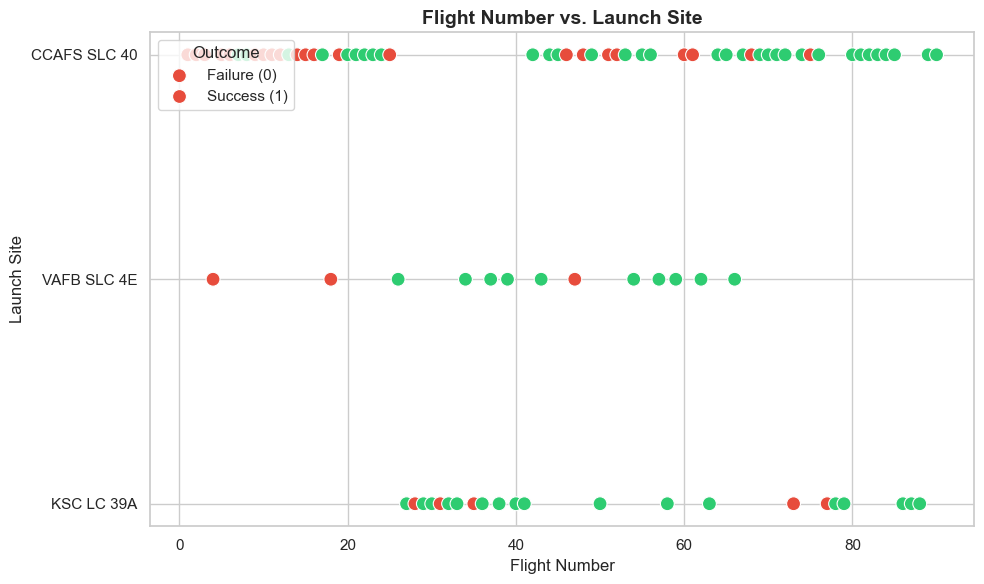

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dataset
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Configurar estilo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Gerar Scatter Plot de Flight Number vs Launch Site
sns.scatterplot(
    data=df, 
    x="FlightNumber", 
    y="LaunchSite", 
    hue="Class", 
    palette={0: "#E74C3C", 1: "#2ECC71"}, 
    s=100
)

plt.title("Flight Number vs. Launch Site", fontsize=14, fontweight='bold')
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.legend(title="Outcome", labels=["Failure (0)", "Success (1)"], loc="upper left")

plt.tight_layout()
plt.savefig("flight_vs_launchsite.png", dpi=300)
plt.show()

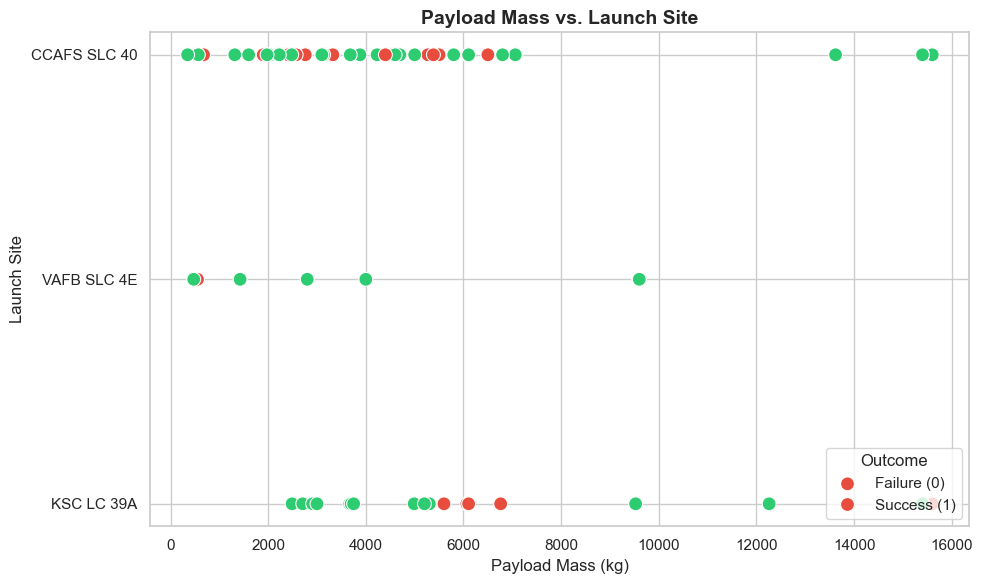

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar o dataset
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# 2. Configurar o gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df, 
    x="PayloadMass", 
    y="LaunchSite", 
    hue="Class", 
    palette={0: "#E74C3C", 1: "#2ECC71"}, 
    s=100
)

plt.title("Payload Mass vs. Launch Site", fontsize=14, fontweight='bold')
plt.xlabel("Payload Mass (kg)", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.legend(title="Outcome", labels=["Failure (0)", "Success (1)"], loc="lower right")

plt.tight_layout()
plt.savefig("payload_vs_launchsite.png", dpi=300)
plt.show()

C:\Users\Keltony A. Ferreira\AppData\Local\Temp\ipykernel_4744\3100392721.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




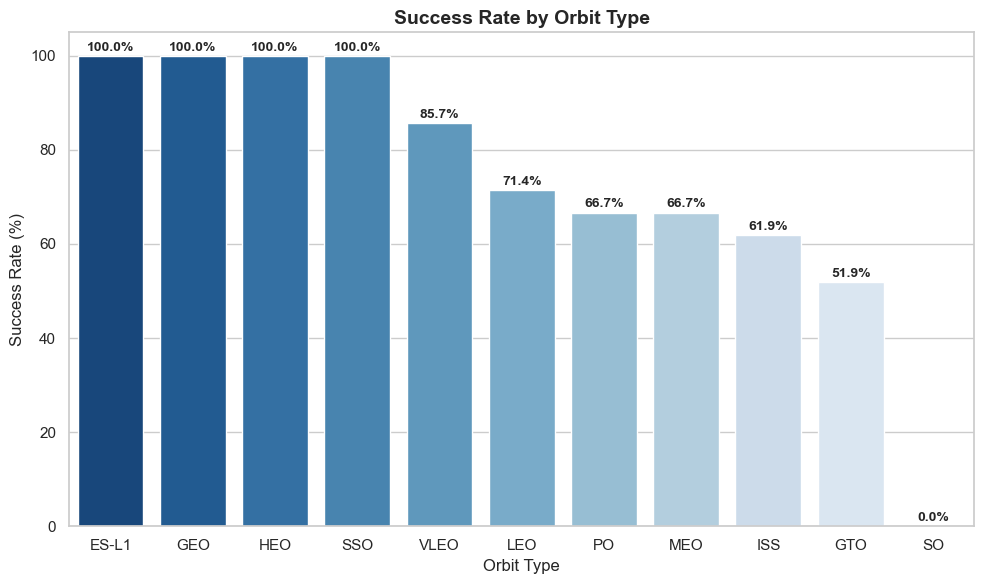

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar o dataset
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# 2. Calcular a taxa média de sucesso por tipo de órbita
df_orbit = df.groupby('Orbit')['Class'].mean().reset_index()
df_orbit['Success Rate (%)'] = df_orbit['Class'] * 100
df_orbit = df_orbit.sort_values(by='Success Rate (%)', ascending=False)

# 3. Configurar e gerar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_orbit, 
    x='Orbit', 
    y='Success Rate (%)', 
    palette='Blues_r'
)

plt.title("Success Rate by Orbit Type", fontsize=14, fontweight='bold')
plt.xlabel("Orbit Type", fontsize=12)
plt.ylabel("Success Rate (%)", fontsize=12)
plt.ylim(0, 105)

# Adicionar os rótulos de porcentagem em cima das barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 6), 
                textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("success_rate_vs_orbit.png", dpi=300)
plt.show()

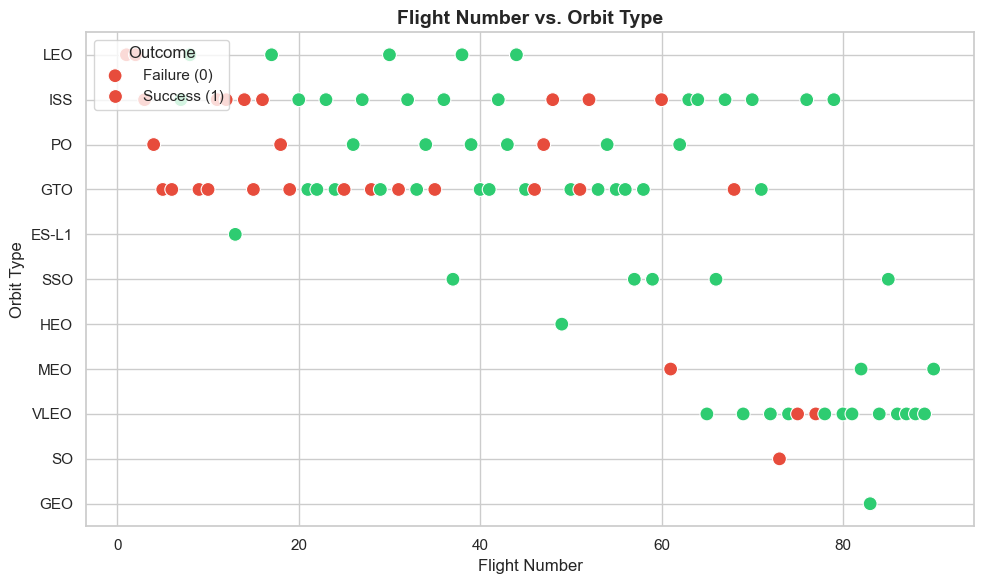

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar o dataset
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# 2. Configurar o gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df, 
    x="FlightNumber", 
    y="Orbit", 
    hue="Class", 
    palette={0: "#E74C3C", 1: "#2ECC71"}, 
    s=100
)

plt.title("Flight Number vs. Orbit Type", fontsize=14, fontweight='bold')
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Orbit Type", fontsize=12)
plt.legend(title="Outcome", labels=["Failure (0)", "Success (1)"], loc="upper left")

plt.tight_layout()
plt.savefig("flight_vs_orbit.png", dpi=300)
plt.show()

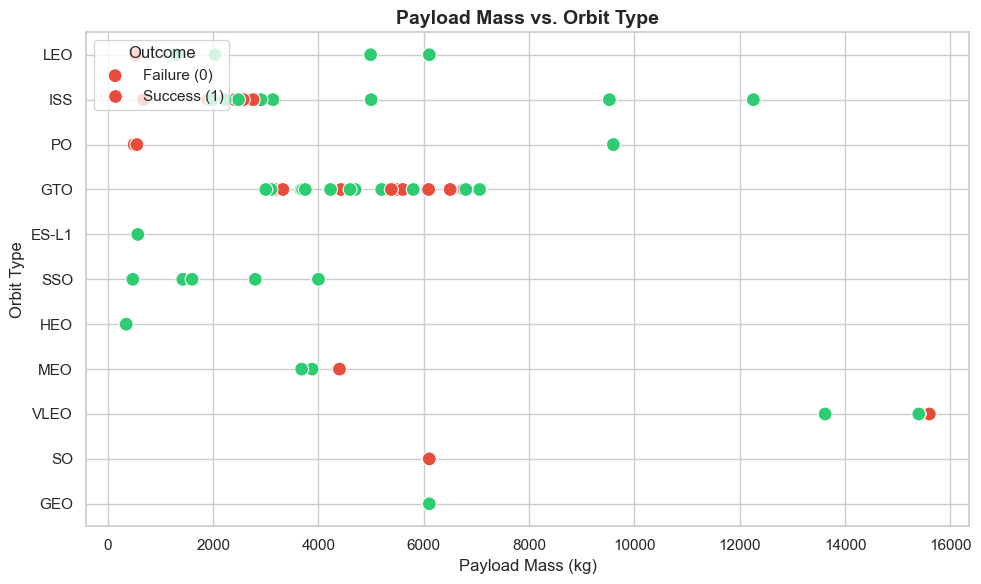

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar o dataset
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# 2. Configurar o gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df, 
    x="PayloadMass", 
    y="Orbit", 
    hue="Class", 
    palette={0: "#E74C3C", 1: "#2ECC71"}, 
    s=100
)

plt.title("Payload Mass vs. Orbit Type", fontsize=14, fontweight='bold')
plt.xlabel("Payload Mass (kg)", fontsize=12)
plt.ylabel("Orbit Type", fontsize=12)
plt.legend(title="Outcome", labels=["Failure (0)", "Success (1)"], loc="upper left")

plt.tight_layout()
plt.savefig("payload_vs_orbit.png", dpi=300)
plt.show()

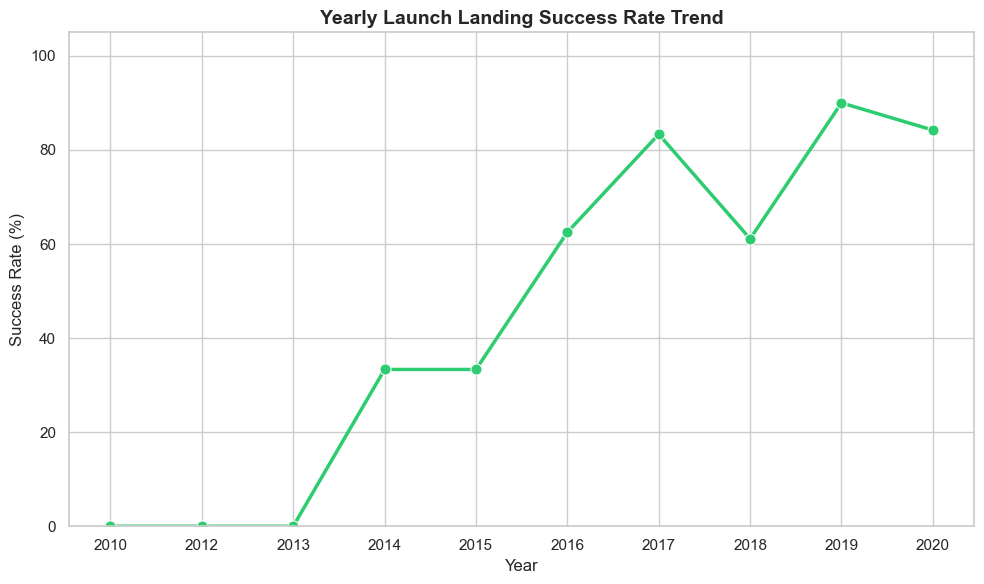

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar o dataset
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# 2. Extrair o ano da coluna Date
year = []
for i in df["Date"]:
    year.append(i.split("-")[0])
df['Year'] = year

# 3. Calcular a taxa média de sucesso por ano
df_yearly = df.groupby('Year')['Class'].mean().reset_index()
df_yearly['Success Rate (%)'] = df_yearly['Class'] * 100

# 4. Configurar e gerar o gráfico de linha
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_yearly, 
    x='Year', 
    y='Success Rate (%)', 
    marker='o', 
    color='#2ECC71', 
    linewidth=2.5, 
    markersize=8
)

plt.title("Yearly Launch Landing Success Rate Trend", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Success Rate (%)", fontsize=12)
plt.ylim(0, 105)

plt.tight_layout()
plt.savefig("yearly_success_trend.png", dpi=300)
plt.show()

In [39]:
import pandas as pd
import sqlite3

# 1. Carregar o CSV do dataset
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# 2. Conectar ao SQLite e gravar os dados na tabela SPACEXTBL
con = sqlite3.connect("my_data1.db")
df.to_sql("SPACEXTBL", con, if_exists='replace', index=False)

# 3. Executar a consulta SQL
query = "SELECT DISTINCT LaunchSite FROM SPACEXTBL;"
df_sites = pd.read_sql(query, con)
df_sites

,LaunchSite
0,CCAFS SLC 40
1,VAFB SLC 4E
2,KSC LC 39A


In [40]:
# Consulta SQL filtrando os 5 primeiros registros que começam com 'CCA'
query = """
SELECT * 
FROM SPACEXTBL 
WHERE LaunchSite LIKE 'CCA%' 
LIMIT 5;
"""

df_cca = pd.read_sql(query, con)
df_cca

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B0007,-80.577366,28.561857,0
3,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B1004,-80.577366,28.561857,0
4,6,2014-01-06,Falcon 9,3325.000000,GTO,CCAFS SLC 40,None None,1,0,0,0,None,1.0,0,B1005,-80.577366,28.561857,0


In [44]:
# Consulta SQL com a coluna no plural (Customers)
pd.read_sql("PRAGMA table_info(SPACEXTBL);", con)['name']

0       FlightNumber
1               Date
2     BoosterVersion
3        PayloadMass
4              Orbit
5         LaunchSite
6            Outcome
7            Flights
8           GridFins
9             Reused
10              Legs
11        LandingPad
12             Block
13       ReusedCount
14            Serial
15         Longitude
16          Latitude
17             Class
Name: name, dtype: object

In [45]:
import pandas as pd
import sqlite3

# 1. Baixar o CSV correto com as colunas do laboratório SQL da IBM
df_sql = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")

# 2. Atualizar a tabela SPACEXTBL
con = sqlite3.connect("my_data1.db")
df_sql.to_sql("SPACEXTBL", con, if_exists='replace', index=False)

# 3. Executar a consulta com os nomes de colunas do laboratório SQL
query = """
SELECT SUM(PAYLOAD_MASS__KG_) AS Total_Payload_Mass_kg
FROM SPACEXTBL 
WHERE Customer LIKE '%NASA%';
"""

df_total_payload = pd.read_sql(query, con)
df_total_payload

,Total_Payload_Mass_kg
0,107010


In [46]:
# Consulta SQL para calcular a massa média de carga útil do booster F9 v1.1
query = """
SELECT AVG(PAYLOAD_MASS__KG_) AS Average_Payload_Mass_kg
FROM SPACEXTBL 
WHERE Booster_Version LIKE 'F9 v1.1%';
"""

df_avg_payload = pd.read_sql(query, con)
df_avg_payload

,Average_Payload_Mass_kg
0,2534.666667


In [47]:
# Consulta SQL para encontrar a data do primeiro pouso bem-sucedido em plataforma terrestre
query = """
SELECT MIN(Date) AS First_Successful_Ground_Landing
FROM SPACEXTBL 
WHERE Landing_Outcome LIKE '%Success (ground pad)%';
"""

df_first_ground = pd.read_sql(query, con)
df_first_ground

,First_Successful_Ground_Landing
0,2015-12-22


In [48]:
# Consulta SQL para listar os boosters que pousaram com sucesso em drone ship com carga entre 4000 e 6000 kg
query = """
SELECT Booster_Version, PAYLOAD_MASS__KG_, Landing_Outcome
FROM SPACEXTBL 
WHERE Landing_Outcome LIKE '%Success (drone ship)%'
  AND PAYLOAD_MASS__KG_ > 4000 
  AND PAYLOAD_MASS__KG_ < 6000;
"""

df_drone_payload = pd.read_sql(query, con)
df_drone_payload

,Booster_Version,PAYLOAD_MASS__KG_,Landing_Outcome
0,F9 FT B1022,4696,Success (drone ship)
1,F9 FT B1026,4600,Success (drone ship)
2,F9 FT B1021.2,5300,Success (drone ship)
3,F9 FT B1031.2,5200,Success (drone ship)


In [49]:
# Consulta SQL para contar os resultados de missão por categoria
query = """
SELECT Mission_Outcome, COUNT(*) AS Count
FROM SPACEXTBL 
GROUP BY Mission_Outcome;
"""

df_mission_outcomes = pd.read_sql(query, con)
df_mission_outcomes

,Mission_Outcome,Count
0,Failure (in flight),1
1,Success,98
2,Success,1
3,Success (payload status unclear),1


In [50]:
# Consulta SQL para listar os boosters que carregaram a massa máxima de carga útil
query = """
SELECT Booster_Version, PAYLOAD_MASS__KG_
FROM SPACEXTBL 
WHERE PAYLOAD_MASS__KG_ = (SELECT MAX(PAYLOAD_MASS__KG_) FROM SPACEXTBL);
"""

df_max_payload = pd.read_sql(query, con)
df_max_payload

,Booster_Version,PAYLOAD_MASS__KG_
0,F9 B5 B1048.4,15600
1,F9 B5 B1049.4,15600
2,F9 B5 B1051.3,15600
3,F9 B5 B1056.4,15600
4,F9 B5 B1048.5,15600
5,F9 B5 B1051.4,15600
6,F9 B5 B1049.5,15600
7,F9 B5 B1060.2,15600
8,F9 B5 B1058.3,15600
9,F9 B5 B1051.6,15600


In [51]:
# Consulta SQL para buscar falhas de pouso em drone ship no ano de 2015
query = """
SELECT Date, Booster_Version, Launch_Site, Landing_Outcome
FROM SPACEXTBL 
WHERE Landing_Outcome LIKE '%Failure (drone ship)%' 
  AND Date LIKE '2015%';
"""

df_2015_failures = pd.read_sql(query, con)
df_2015_failures

,Date,Booster_Version,Launch_Site,Landing_Outcome
0,2015-01-10,F9 v1.1 B1012,CCAFS LC-40,Failure (drone ship)
1,2015-04-14,F9 v1.1 B1015,CCAFS LC-40,Failure (drone ship)


In [52]:
# Consulta SQL para ranquear os resultados de pouso no intervalo de datas em ordem decrescente
query = """
SELECT Landing_Outcome, COUNT(*) AS Outcome_Count
FROM SPACEXTBL 
WHERE Date BETWEEN '2010-06-04' AND '2017-03-20'
GROUP BY Landing_Outcome
ORDER BY Outcome_Count DESC;
"""

df_ranked_outcomes = pd.read_sql(query, con)
df_ranked_outcomes

,Landing_Outcome,Outcome_Count
0,No attempt,10
1,Success (drone ship),5
2,Failure (drone ship),5
3,Success (ground pad),3
4,Controlled (ocean),3
5,Uncontrolled (ocean),2
6,Failure (parachute),2
7,Precluded (drone ship),1


In [53]:
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    # Raio da Terra em quilômetros
    R = 6373.0

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

In [54]:
import folium
from folium.features import DivIcon

# Coordenadas do local de lançamento (Exemplo: KSC LC-39A)
launch_site_lat = 28.573255
launch_site_lon = -80.646895

# Coordenadas do ponto de interesse mais próximo (Exemplo: Ponto na Costa/Oceano)
coastline_lat = 28.56367
coastline_lon = -80.56763

# 1. Calcular a distância em km
distance_coastline = calculate_distance(launch_site_lat, launch_site_lon, coastline_lat, coastline_lon)

# 2. Criar o marcador com o valor da distância (Texto no mapa)
distance_marker = folium.Marker(
    [coastline_lat, coastline_lon],
    icon=DivIcon(
        icon_size=(20, 20),
        icon_anchor=(0, 0),
        html='<div style="font-size: 12pt; color:#d9534f;"><b>{:0.2f} KM</b></div>'.format(distance_coastline),
    )
)
site_map.add_child(distance_marker)

# 3. Desenhar a linha conectando o local de lançamento ao ponto de interesse
lines = folium.PolyLine(
    locations=[[launch_site_lat, launch_site_lon], [coastline_lat, coastline_lon]], 
    weight=2, 
    color='blue'
)
site_map.add_child(lines)

# Exibir o mapa atualizado
site_map

In [56]:
# Baixa e carrega o CSV direto da fonte da IBM
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv"
spacex_df = pd.read_csv(url)

In [58]:
import pandas as pd
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px

# 1. Carregar os dados da SpaceX
spacex_df = pd.read_csv("spacex_launch_dash.csv")
max_payload = spacex_df['Payload Mass (kg)'].max()
min_payload = spacex_df['Payload Mass (kg)'].min()

# 2. Inicializar a aplicação Dash
app = dash.Dash(__name__)

# 3. Layout da Aplicação
app.layout = html.Div(children=[
    html.H1(
        'SpaceX Launch Records Dashboard',
        style={'textAlign': 'center', 'color': '#503D36', 'font-size': 40}
    ),
    
    # TASK 1: Dropdown para seleção do local de lançamento
    dcc.Dropdown(
        id='site-dropdown',
        options=[
            {'label': 'All Sites', 'value': 'ALL'},
            {'label': 'CCAFS LC-40', 'value': 'CCAFS LC-40'},
            {'label': 'VAFB SLC-4E', 'value': 'VAFB SLC-4E'},
            {'label': 'KSC LC-39A', 'value': 'KSC LC-39A'},
            {'label': 'CCAFS SLC-40', 'value': 'CCAFS SLC-40'},
        ],
        value='ALL',
        placeholder="Select a Launch Site here",
        searchable=True
    ),
    html.Br(),

    # TASK 2: Gráfico de Pizza (Pie Chart)
    html.Div(dcc.Graph(id='success-pie-chart')),
    html.Br(),

    html.P("Payload range (Kg):"),
    
    # TASK 3: Range Slider para filtro de carga útil
    dcc.RangeSlider(
        id='payload-slider',
        min=0,
        max=10000,
        step=1000,
        marks={i: f'{i}' for i in range(0, 10001, 2500)},
        value=[min_payload, max_payload]
    ),

    # TASK 4: Gráfico de Dispersão (Scatter Plot)
    html.Div(dcc.Graph(id='success-payload-scatter-chart')),
])

# -----------------------------------------------------------------------------
# CALLBACKS

# TASK 2: Callback para atualizar o Pie Chart
@app.callback(
    Output(component_id='success-pie-chart', component_property='figure'),
    Input(component_id='site-dropdown', component_property='value')
)
def get_pie_chart(entered_site):
    if entered_site == 'ALL':
        # Filtra apenas os lançamentos com sucesso (class = 1) e agrupa por site
        fig = px.pie(
            spacex_df, 
            values='class', 
            names='Launch Site', 
            title='Total Success Launches By Site'
        )
        return fig
    else:
        # Filtra o dataframe pelo site selecionado e conta os sucessos/falhas (0 e 1)
        filtered_df = spacex_df[spacex_df['Launch Site'] == entered_site]
        site_counts = filtered_df['class'].value_counts().reset_index()
        site_counts.columns = ['class', 'count']
        site_counts['class_name'] = site_counts['class'].map({1: 'Success', 0: 'Failure'})
        
        fig = px.pie(
            site_counts, 
            values='count', 
            names='class_name', 
            title=f'Total Success Launches for site {entered_site}',
            color='class_name',
            color_discrete_map={'Success': 'green', 'Failure': 'red'}
        )
        return fig

# TASK 4: Callback para atualizar o Scatter Plot
@app.callback(
    Output(component_id='success-payload-scatter-chart', component_property='figure'),
    [
        Input(component_id='site-dropdown', component_property='value'),
        Input(component_id='payload-slider', component_property='value')
    ]
)
def get_scatter_chart(entered_site, payload_range):
    low, high = payload_range
    # Filtrar os dados pelo intervalo do slider
    mask = (spacex_df['Payload Mass (kg)'] >= low) & (spacex_df['Payload Mass (kg)'] <= high)
    filtered_df = spacex_df[mask]

    if entered_site == 'ALL':
        fig = px.scatter(
            filtered_df,
            x='Payload Mass (kg)',
            y='class',
            color='Booster Version Category',
            title='Correlation between Payload and Success for all Sites'
        )
        return fig
    else:
        # Filtrar também pelo site selecionado
        site_df = filtered_df[filtered_df['Launch Site'] == entered_site]
        fig = px.scatter(
            site_df,
            x='Payload Mass (kg)',
            y='class',
            color='Booster Version Category',
            title=f'Correlation between Payload and Success for site {entered_site}'
        )
        return fig

# 4. Rodar o servidor
if __name__ == '__main__':
    app.run_server(port=8050)

FileNotFoundError: [Errno 2] No such file or directory: 'spacex_launch_dash.csv'

In [59]:
spacex_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv")

In [60]:
import pandas as pd
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px

# 1. Carregar os dados da SpaceX diretamente da URL oficial da IBM
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv"
spacex_df = pd.read_csv(url)

max_payload = spacex_df['Payload Mass (kg)'].max()
min_payload = spacex_df['Payload Mass (kg)'].min()

# 2. Inicializar a aplicação Dash
app = dash.Dash(__name__)

# 3. Layout da Aplicação
app.layout = html.Div(children=[
    html.H1(
        'SpaceX Launch Records Dashboard',
        style={'textAlign': 'center', 'color': '#503D36', 'font-size': 40}
    ),
    
    # TASK 1: Dropdown para seleção do local de lançamento
    dcc.Dropdown(
        id='site-dropdown',
        options=[
            {'label': 'All Sites', 'value': 'ALL'},
            {'label': 'CCAFS LC-40', 'value': 'CCAFS LC-40'},
            {'label': 'VAFB SLC-4E', 'value': 'VAFB SLC-4E'},
            {'label': 'KSC LC-39A', 'value': 'KSC LC-39A'},
            {'label': 'CCAFS SLC-40', 'value': 'CCAFS SLC-40'},
        ],
        value='ALL',
        placeholder="Select a Launch Site here",
        searchable=True
    ),
    html.Br(),

    # TASK 2: Gráfico de Pizza (Pie Chart)
    html.Div(dcc.Graph(id='success-pie-chart')),
    html.Br(),

    html.P("Payload range (Kg):"),
    
    # TASK 3: Range Slider para filtro de carga útil
    dcc.RangeSlider(
        id='payload-slider',
        min=0,
        max=10000,
        step=1000,
        marks={i: f'{i}' for i in range(0, 10001, 2500)},
        value=[min_payload, max_payload]
    ),

    # TASK 4: Gráfico de Dispersão (Scatter Plot)
    html.Div(dcc.Graph(id='success-payload-scatter-chart')),
])

# -----------------------------------------------------------------------------
# CALLBACKS

# TASK 2: Callback para atualizar o Pie Chart
@app.callback(
    Output(component_id='success-pie-chart', component_property='figure'),
    Input(component_id='site-dropdown', component_property='value')
)
def get_pie_chart(entered_site):
    if entered_site == 'ALL':
        fig = px.pie(
            spacex_df, 
            values='class', 
            names='Launch Site', 
            title='Total Success Launches By Site'
        )
        return fig
    else:
        filtered_df = spacex_df[spacex_df['Launch Site'] == entered_site]
        site_counts = filtered_df['class'].value_counts().reset_index()
        site_counts.columns = ['class', 'count']
        site_counts['class_name'] = site_counts['class'].map({1: 'Success', 0: 'Failure'})
        
        fig = px.pie(
            site_counts, 
            values='count', 
            names='class_name', 
            title=f'Total Success Launches for site {entered_site}',
            color='class_name',
            color_discrete_map={'Success': 'green', 'Failure': 'red'}
        )
        return fig

# TASK 4: Callback para atualizar o Scatter Plot
@app.callback(
    Output(component_id='success-payload-scatter-chart', component_property='figure'),
    [
        Input(component_id='site-dropdown', component_property='value'),
        Input(component_id='payload-slider', component_property='value')
    ]
)
def get_scatter_chart(entered_site, payload_range):
    low, high = payload_range
    mask = (spacex_df['Payload Mass (kg)'] >= low) & (spacex_df['Payload Mass (kg)'] <= high)
    filtered_df = spacex_df[mask]

    if entered_site == 'ALL':
        fig = px.scatter(
            filtered_df,
            x='Payload Mass (kg)',
            y='class',
            color='Booster Version Category',
            title='Correlation between Payload and Success for all Sites'
        )
        return fig
    else:
        site_df = filtered_df[filtered_df['Launch Site'] == entered_site]
        fig = px.scatter(
            site_df,
            x='Payload Mass (kg)',
            y='class',
            color='Booster Version Category',
            title=f'Correlation between Payload and Success for site {entered_site}'
        )
        return fig

# 4. Rodar o servidor compatível com Jupyter Notebook no VS Code
if __name__ == '__main__':
    app.run(jupyter_mode="external", port=8050)

Dash app running on http://127.0.0.1:8050/
